In [6]:
import pandas as pd
import numpy as np
from codelib.file_management.dynamic_file_pathing import get_root
import os
from codelib.Models.vasicek_model import VasicekEstimatorSimple
from codelib.Models.vasicek_model import VasicekSimulation
import matplotlib.pyplot as plt

from typing import Union

# numpy for working with matrices, etc.
import numpy as np

# import pandas
import pandas as pd

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# scipy for statistics and optimization
from scipy import optimize
from scipy import stats

# import cvxpy
import cvxpy as cp

# function to perform interpolation

"""
functions from codelib
"""

# functions for calculating moments
from codelib.Johan.statistics import moments as mom

# functions for calculating risk metrics
from codelib.Johan.portfolio_optimization import risk_metrics as rm

# functions for risk budgetting
from codelib.Johan.portfolio_optimization import risk_metrics as rb

# functions for mean-variance optimization
from codelib.Johan.portfolio_optimization import mean_variance as mvo

# cash flows
from codelib.Johan.fixed_income.cash_flows import CashFlow

# predefined plots
from codelib.Johan.visualization.base import fan_chart

# Estimate Vasicek Parameters and risk premium

## Load data

In [7]:
root = get_root()
data = os.path.join(root, "Simulation", "Bonds", "Data", "monthly_rates2.xlsx")

## Estimate parameters

In [8]:
estimator = VasicekEstimatorSimple(data, 12)
kappa, theta, beta = estimator.estimate_params()
rp = estimator.estimate_risk_premium()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.982
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                 1.293e+04
Date:                Fri, 28 Mar 2025   Prob (F-statistic):          9.27e-209
Time:                        16:11:33   Log-Likelihood:                 1126.2
No. Observations:                 239   AIC:                            -2248.
Df Residuals:                     237   BIC:                            -2241.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.635      0.5

# Simulate Short Rate

In [9]:
#Simulation definition
num_sim = 10000
dt = 1.0 / 12
horizon = 50
num_time_steps = int(horizon / dt)
time_points = np.arange(0, num_time_steps + 1, 1) * dt

sim_model = VasicekSimulation(data, 12, kappa, theta, beta)
short_rates = sim_model.simulate(horizon, 10000)

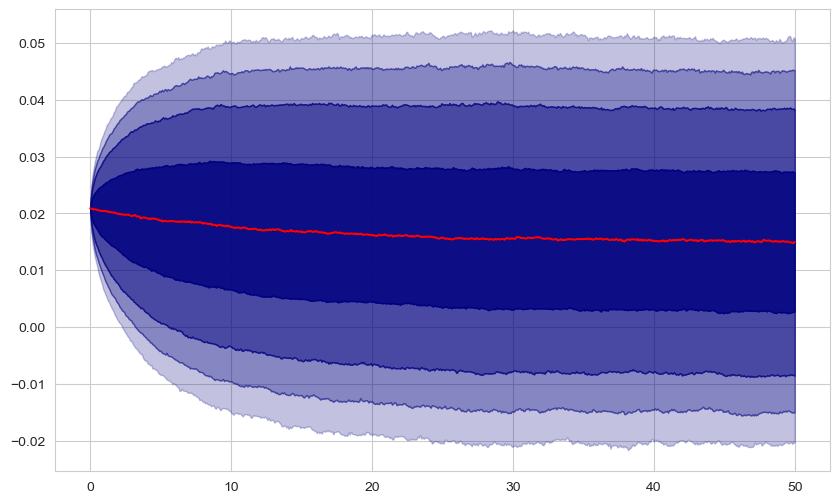

In [10]:
"""
Plot fan chart of short rates
"""
percentiles = np.percentile(short_rates, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

### Simulate Zero Coupon bond prices

In [11]:
"""
Define functions for calculating zero coupon bond prices
"""


def calculate_zero_coupon_yield(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float):

    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)

    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2

    return (a + b * initial_short_rate) / time_to_maturity

def calculate_zero_coupon_price(time_to_maturity: Union[float, np.ndarray],
                                initial_short_rate: float,
                                kappa: float,
                                theta: float,
                                beta: float,
                                risk_premium: float):

    y_infty = theta - risk_premium * beta / kappa - beta**2 / (2 * kappa**2)

    b = 1 / kappa * (1 - np.exp(-kappa * time_to_maturity))
    a = y_infty * (time_to_maturity  - b) + beta**2 / (4 * kappa) * b**2

    return np.exp(- a - b * initial_short_rate)

In [12]:
"""
Simulate zero coupon bond yields for maturities 10y and 10y - delta t
"""

zcb_10y_mv = np.zeros((num_sim, num_time_steps + 1))
zcb_10y_minus_delta_t = np.zeros((num_sim, num_time_steps + 1))

for i, t in enumerate(time_points):
    zcb_10y_mv[:, i] = calculate_zero_coupon_yield(10.0, short_rates[:, i], kappa, theta, beta, rp)
    zcb_10y_minus_delta_t[:, i] = calculate_zero_coupon_yield(10.0 - dt, short_rates[:, i], kappa, theta, beta, rp)

In [13]:
"""
Simulate zero coupon bond prices for maturities 10y and 10y - delta t
"""


zcb_10y_mv = np.zeros((num_sim, num_time_steps + 1))
zcb_10y_minus_delta_t = np.zeros((num_sim, num_time_steps + 1))

for i, t in enumerate(time_points):
    zcb_10y_mv[:, i] = calculate_zero_coupon_price(10.0, short_rates[:, i], kappa, theta, beta, rp)
    zcb_10y_minus_delta_t[:, i] = calculate_zero_coupon_price(10.0 - dt, short_rates[:, i], kappa, theta, beta, rp)

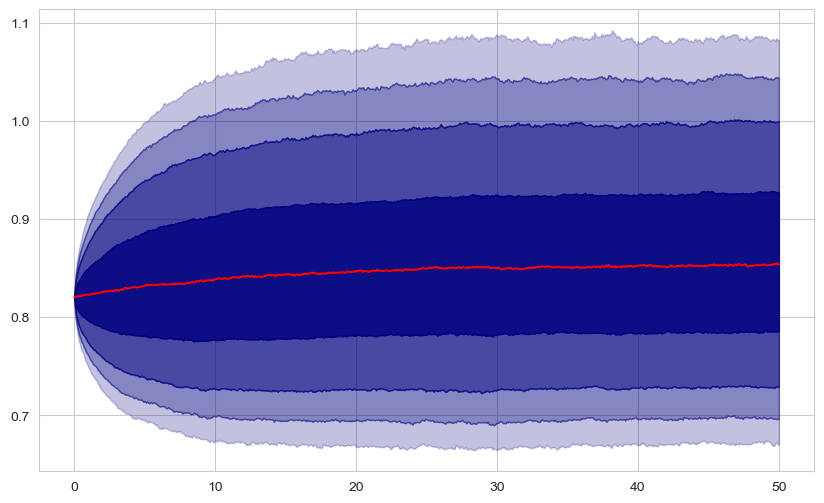

In [14]:
"""
Plot fan chart of zero coupon bond prices
"""
percentiles = np.percentile(zcb_10y_mv, [2.5, 5, 10, 25, 50, 75, 90, 95, 97.5], axis=0)

fig, ax = plt.subplots(figsize=(10, 6))
fan_chart(time_points, percentiles, ax=ax, color="navy")

In [17]:
zcb_10y_mv = pd.DataFrame(zcb_10y_mv)
zcb_10y_mv.to_excel(r"/Users/osito/Repositories/AEF_thesis_GBI/GBI Optimisation/Data/Bond returns/bond_prices_monthly.xlsx")